In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler


df = pd.read_csv("Mall_Customers.csv")
print(df.head())
print(df.info())


data = df.copy()


le = LabelEncoder()
data["Genre"] = le.fit_transform(data["Genre"])   # Male/Female -> 0/1

X = data[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
[[-1.42456879 -1.73899919 -0.43480148]
 [-1.2810354

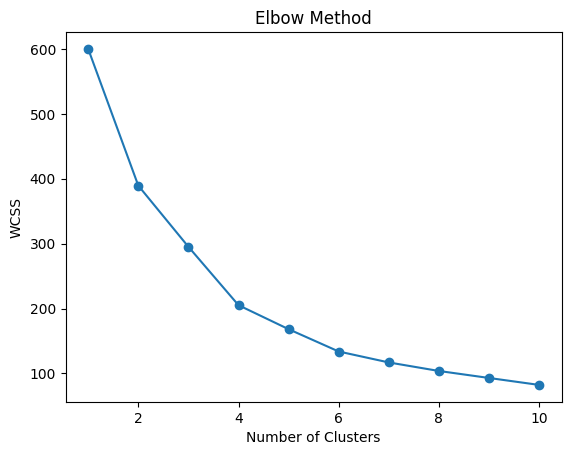

   CustomerID  Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1      1   19                  15                      39   
1           2      1   21                  15                      81   
2           3      0   20                  16                       6   
3           4      0   23                  16                      77   
4           5      0   31                  17                      40   

   KMeans_Cluster  
0               1  
1               1  
2               0  
3               1  
4               1  


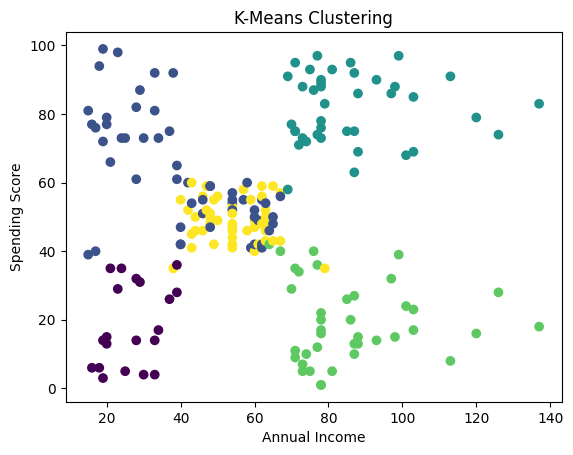

In [2]:

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)

data["KMeans_Cluster"] = y_kmeans
print(data.head())


plt.scatter(data["Annual Income (k$)"], data["Spending Score (1-100)"], c=y_kmeans)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("K-Means Clustering")
plt.show()

   Age  Annual Income (k$)  Spending Score (1-100)  Affinity_Cluster
0   19                  15                      39                 3
1   21                  15                      81                 0
2   20                  16                       6                 2
3   23                  16                      77                 0
4   31                  17                      40                 2


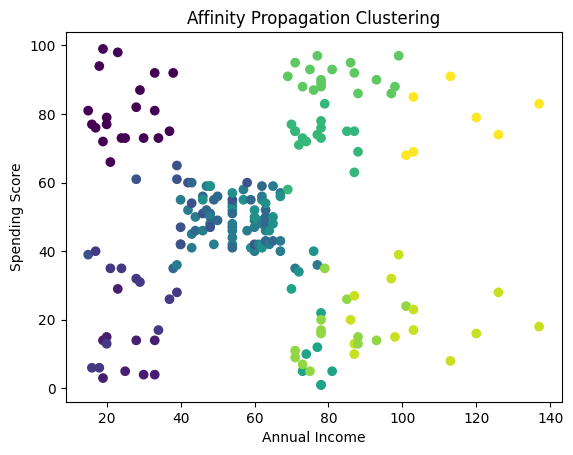

In [3]:

from sklearn.cluster import AffinityPropagation

ap = AffinityPropagation(random_state=42)
y_ap = ap.fit_predict(X_scaled)

data["Affinity_Cluster"] = y_ap
print(data[["Age", "Annual Income (k$)", "Spending Score (1-100)", "Affinity_Cluster"]].head())

plt.scatter(data["Annual Income (k$)"], data["Spending Score (1-100)"], c=y_ap)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Affinity Propagation Clustering")
plt.show()

   Age  Annual Income (k$)  Spending Score (1-100)  MeanShift_Cluster
0   19                  15                      39                  0
1   21                  15                      81                  0
2   20                  16                       6                  0
3   23                  16                      77                  0
4   31                  17                      40                  0


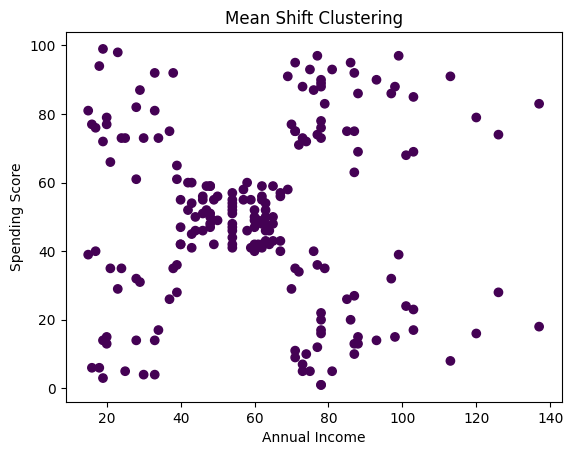

In [4]:

from sklearn.cluster import MeanShift

ms = MeanShift()
y_ms = ms.fit_predict(X_scaled)

data["MeanShift_Cluster"] = y_ms
print(data[["Age", "Annual Income (k$)", "Spending Score (1-100)", "MeanShift_Cluster"]].head())

plt.scatter(data["Annual Income (k$)"], data["Spending Score (1-100)"], c=y_ms)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Mean Shift Clustering")
plt.show()

   Age  Annual Income (k$)  Spending Score (1-100)  Spectral_Cluster
0   19                  15                      39                 2
1   21                  15                      81                 0
2   20                  16                       6                 2
3   23                  16                      77                 0
4   31                  17                      40                 2


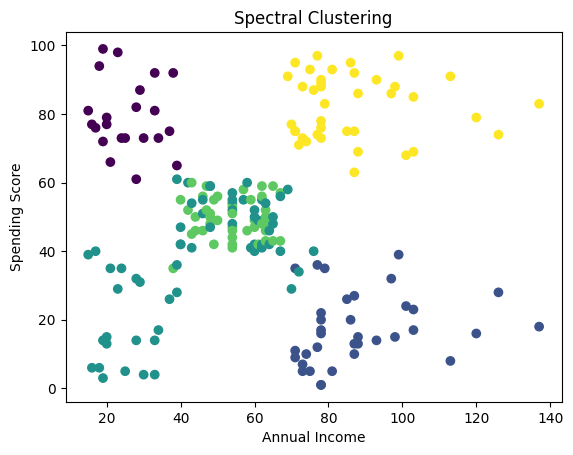

In [5]:
from sklearn.cluster import SpectralClustering

sc = SpectralClustering(n_clusters=5, affinity='nearest_neighbors', random_state=42)
y_sc = sc.fit_predict(X_scaled)

data["Spectral_Cluster"] = y_sc
print(data[["Age", "Annual Income (k$)", "Spending Score (1-100)", "Spectral_Cluster"]].head())

plt.scatter(data["Annual Income (k$)"], data["Spending Score (1-100)"], c=y_sc)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Spectral Clustering")
plt.show()

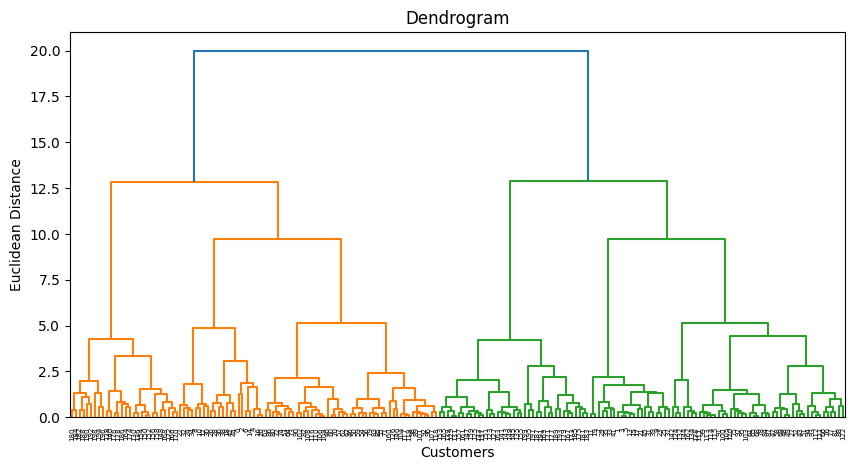

   Age  Annual Income (k$)  Spending Score (1-100)  Hierarchical_Cluster
0   19                  15                      39                     4
1   21                  15                      81                     0
2   20                  16                       6                     4
3   23                  16                      77                     0
4   31                  17                      40                     4


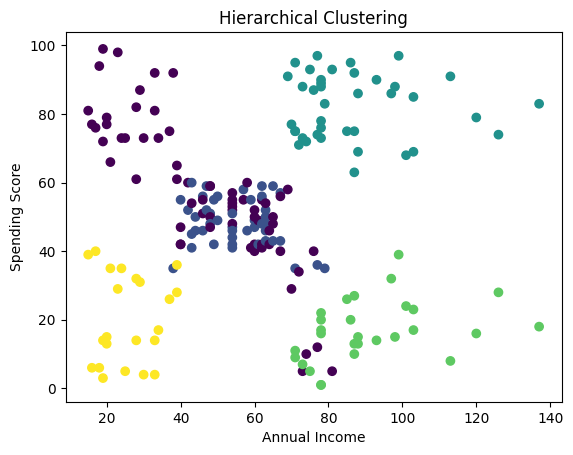

In [6]:

import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering


plt.figure(figsize=(10, 5))
sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()

hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X_scaled)

data["Hierarchical_Cluster"] = y_hc
print(data[["Age", "Annual Income (k$)", "Spending Score (1-100)", "Hierarchical_Cluster"]].head())

plt.scatter(data["Annual Income (k$)"], data["Spending Score (1-100)"], c=y_hc)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Hierarchical Clustering")
plt.show()

   Age  Annual Income (k$)  Spending Score (1-100)  DBSCAN_Cluster
0   19                  15                      39              -1
1   21                  15                      81               0
2   20                  16                       6              -1
3   23                  16                      77               0
4   31                  17                      40               0


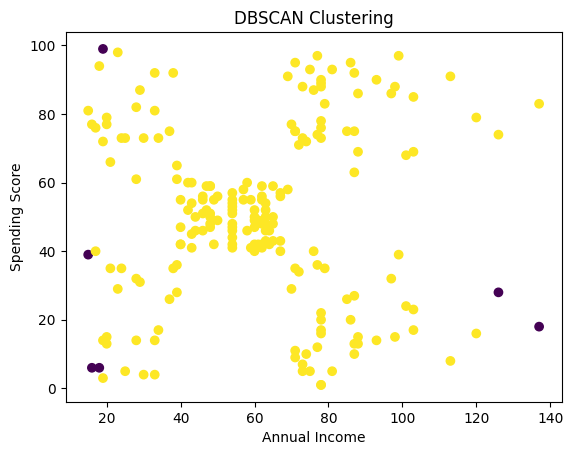

In [7]:

from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.8, min_samples=5)
y_db = db.fit_predict(X_scaled)

data["DBSCAN_Cluster"] = y_db
print(data[["Age", "Annual Income (k$)", "Spending Score (1-100)", "DBSCAN_Cluster"]].head())

plt.scatter(data["Annual Income (k$)"], data["Spending Score (1-100)"], c=y_db)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("DBSCAN Clustering")
plt.show()

   Age  Annual Income (k$)  Spending Score (1-100)  OPTICS_Cluster
0   19                  15                      39              -1
1   21                  15                      81              -1
2   20                  16                       6              -1
3   23                  16                      77              -1
4   31                  17                      40              -1


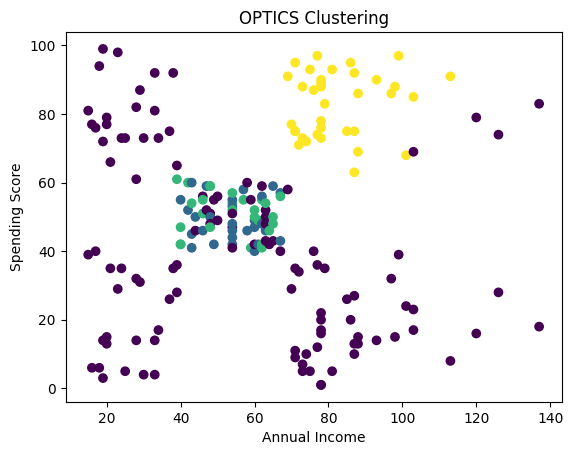

In [8]:

from sklearn.cluster import OPTICS

optics = OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.1)
y_optics = optics.fit_predict(X_scaled)

data["OPTICS_Cluster"] = y_optics
print(data[["Age", "Annual Income (k$)", "Spending Score (1-100)", "OPTICS_Cluster"]].head())

plt.scatter(data["Annual Income (k$)"], data["Spending Score (1-100)"], c=y_optics)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("OPTICS Clustering")
plt.show()

   Age  Annual Income (k$)  Spending Score (1-100)  BIRCH_Cluster
0   19                  15                      39              1
1   21                  15                      81              3
2   20                  16                       6              1
3   23                  16                      77              3
4   31                  17                      40              1


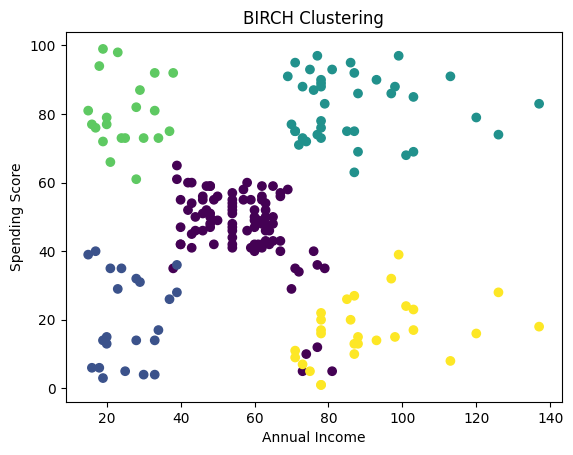

In [9]:

from sklearn.cluster import Birch

birch = Birch(n_clusters=5)
y_birch = birch.fit_predict(X_scaled)

data["BIRCH_Cluster"] = y_birch
print(data[["Age", "Annual Income (k$)", "Spending Score (1-100)", "BIRCH_Cluster"]].head())

plt.scatter(data["Annual Income (k$)"], data["Spending Score (1-100)"], c=y_birch)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("BIRCH Clustering")
plt.show()

In [11]:

from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score


print("Silhouette Score:", silhouette_score(X_scaled, y_kmeans))
print("Calinski-Harabasz Score:", calinski_harabasz_score(X_scaled, y_kmeans))
print("Davies-Bouldin Score:", davies_bouldin_score(X_scaled, y_kmeans))
print("DBSCAN Silhouette:", silhouette_score(X_scaled, y_db))
print("BIRCH Silhouette:", silhouette_score(X_scaled, y_birch))
print("Hierarchical Silhouette:", silhouette_score(X_scaled, y_hc))

Silhouette Score: 0.41664341513732767
Calinski-Harabasz Score: 125.10094020060954
Davies-Bouldin Score: 0.874551051002418
DBSCAN Silhouette: 0.2543987042290558
BIRCH Silhouette: 0.3231018259851066
Hierarchical Silhouette: 0.39002826186267214
